In [9]:
import fastf1
import fastf1.plotting 
import os

# Create cache directory and enable FastF1 caching
os.makedirs("f1_cache", exist_ok=True)
fastf1.Cache.enable_cache("f1_cache")

print("Setup complete!") 

Setup complete!


In [10]:
# Load Monza 2024 Qualifying session and all lap data
session = fastf1.get_session(2024, "Monza", "Q")
session.load()

laps = session.laps
print(f"Laps loaded: {len(laps)}") 

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '63', '16', '55', '44', '1', '11', '23', '27', '14', '3', '20', '10', '31', '22', '18', '43', '77', '24']


Laps loaded: 276


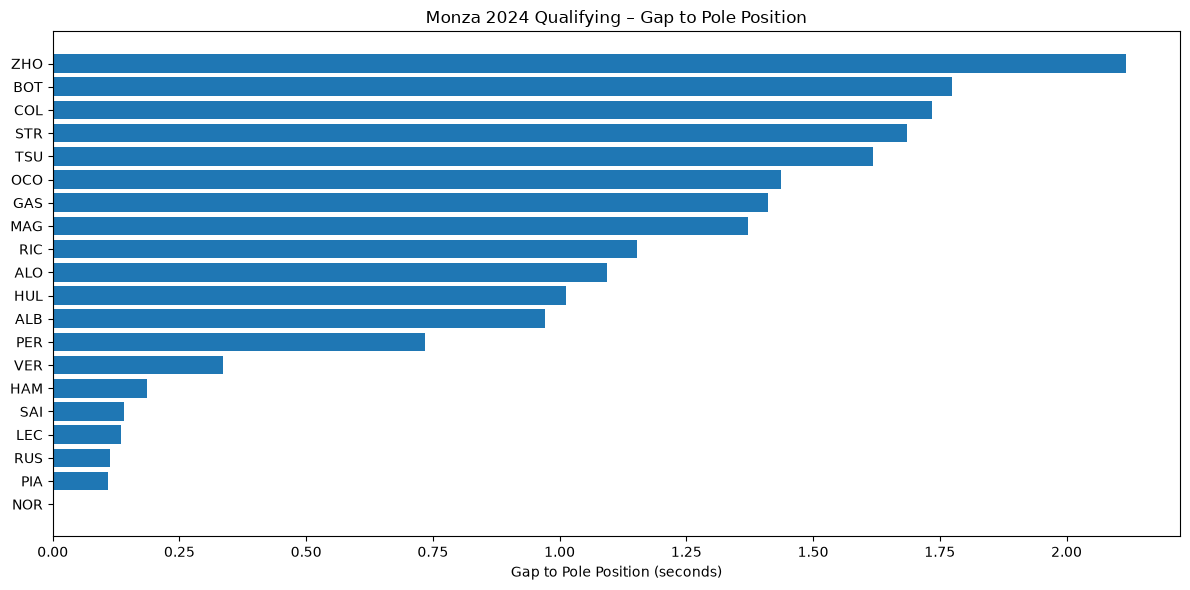

In [11]:
import matplotlib.pyplot as plt

# Get the fastest lap per driver, only counting quick laps
fastest_laps = laps.pick_quicklaps().groupby("Driver")["LapTime"].min().sort_values()

# Convert to seconds for a readable axis
fastest_seconds = fastest_laps.dt.total_seconds()

# Plot the gap to pole position for each driver
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(fastest_seconds.index, fastest_seconds.values - fastest_seconds.min())
ax.set_xlabel("Gap to Pole Position (seconds)")
ax.set_title("Monza 2024 Qualifying – Gap to Pole Position")
plt.tight_layout()
plt.show() 

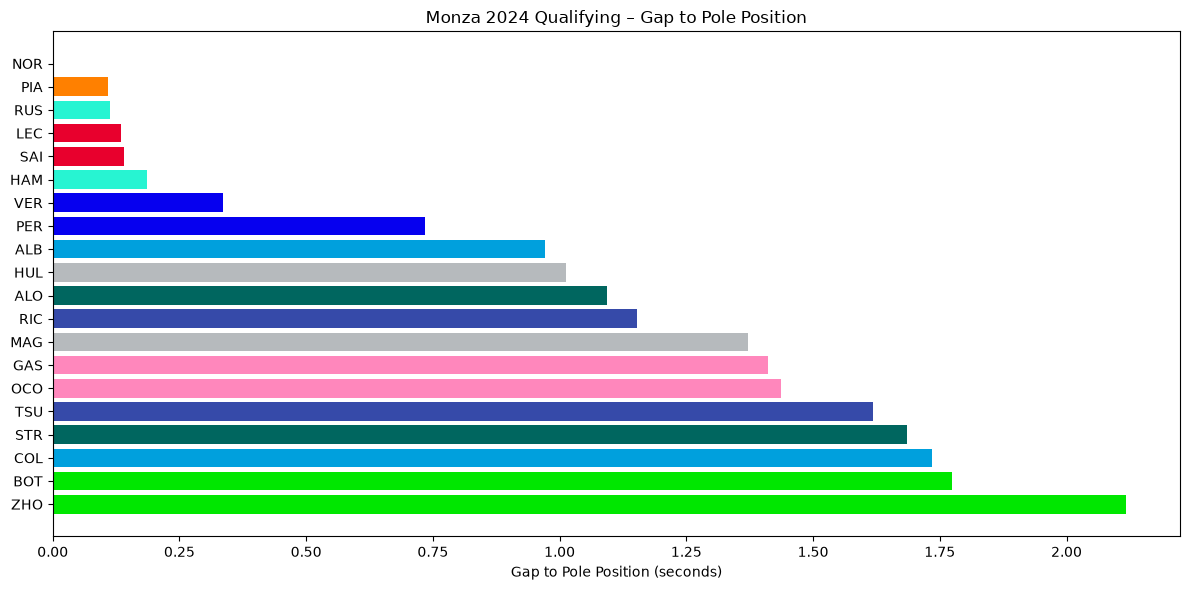

In [12]:
# Set up matplotlib with FastF1 styling
fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme=None)

fastest_laps = laps.pick_quicklaps().groupby("Driver")["LapTime"].min().sort_values()
fastest_seconds = fastest_laps.dt.total_seconds()

# Assign official team color to each driver
colors = []
for driver in fastest_seconds.index:
    team = laps[laps["Driver"] == driver]["Team"].iloc[0]
    color = fastf1.plotting.get_team_color(team, session=session)
    colors.append(color)

# Plot gap to pole with official team colors
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(fastest_seconds.index, fastest_seconds.values - fastest_seconds.min(), color=colors)
ax.set_xlabel("Gap to Pole Position (seconds)")
ax.set_title("Monza 2024 Qualifying – Gap to Pole Position")
ax.invert_yaxis()
plt.tight_layout()
plt.show() 

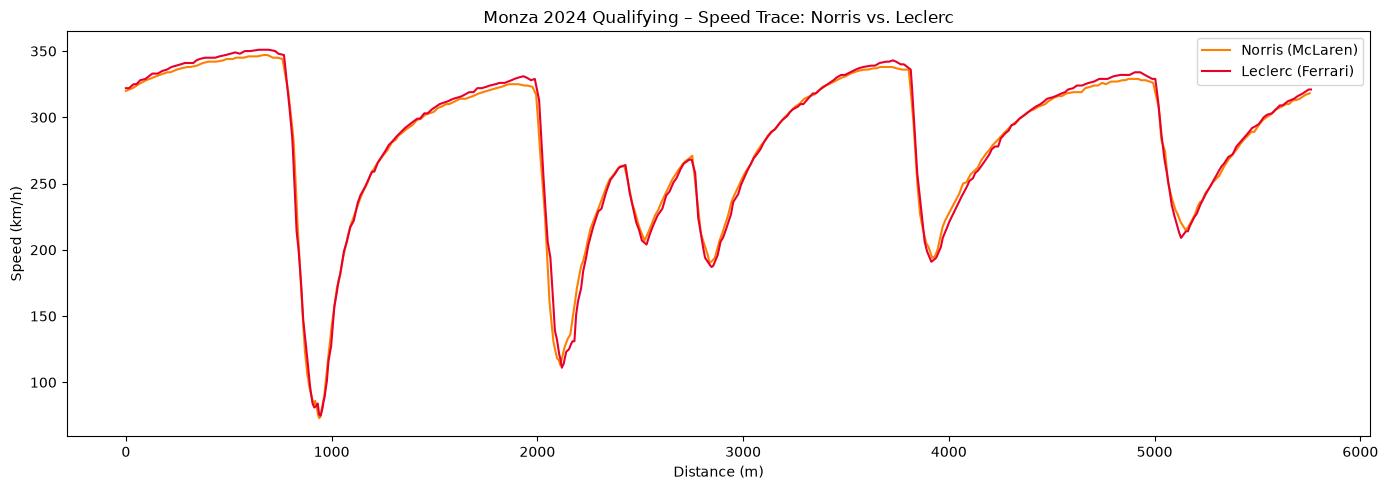

In [13]:
# Get the fastest lap for Norris and Leclerc
nor = laps.pick_drivers("NOR").pick_fastest()
lec = laps.pick_drivers("LEC").pick_fastest()

# Load telemetry data for both drivers
tel_nor = nor.get_telemetry()
tel_lec = lec.get_telemetry()

# Plot speed trace over lap distance
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(tel_nor["Distance"], tel_nor["Speed"], 
        color=fastf1.plotting.get_team_color("McLaren", session=session), 
        label="Norris (McLaren)")

ax.plot(tel_lec["Distance"], tel_lec["Speed"], 
        color=fastf1.plotting.get_team_color("Ferrari", session=session), 
        label="Leclerc (Ferrari)")

ax.set_xlabel("Distance (m)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Monza 2024 Qualifying – Speed Trace: Norris vs. Leclerc")
ax.legend()
plt.tight_layout()
plt.show() 

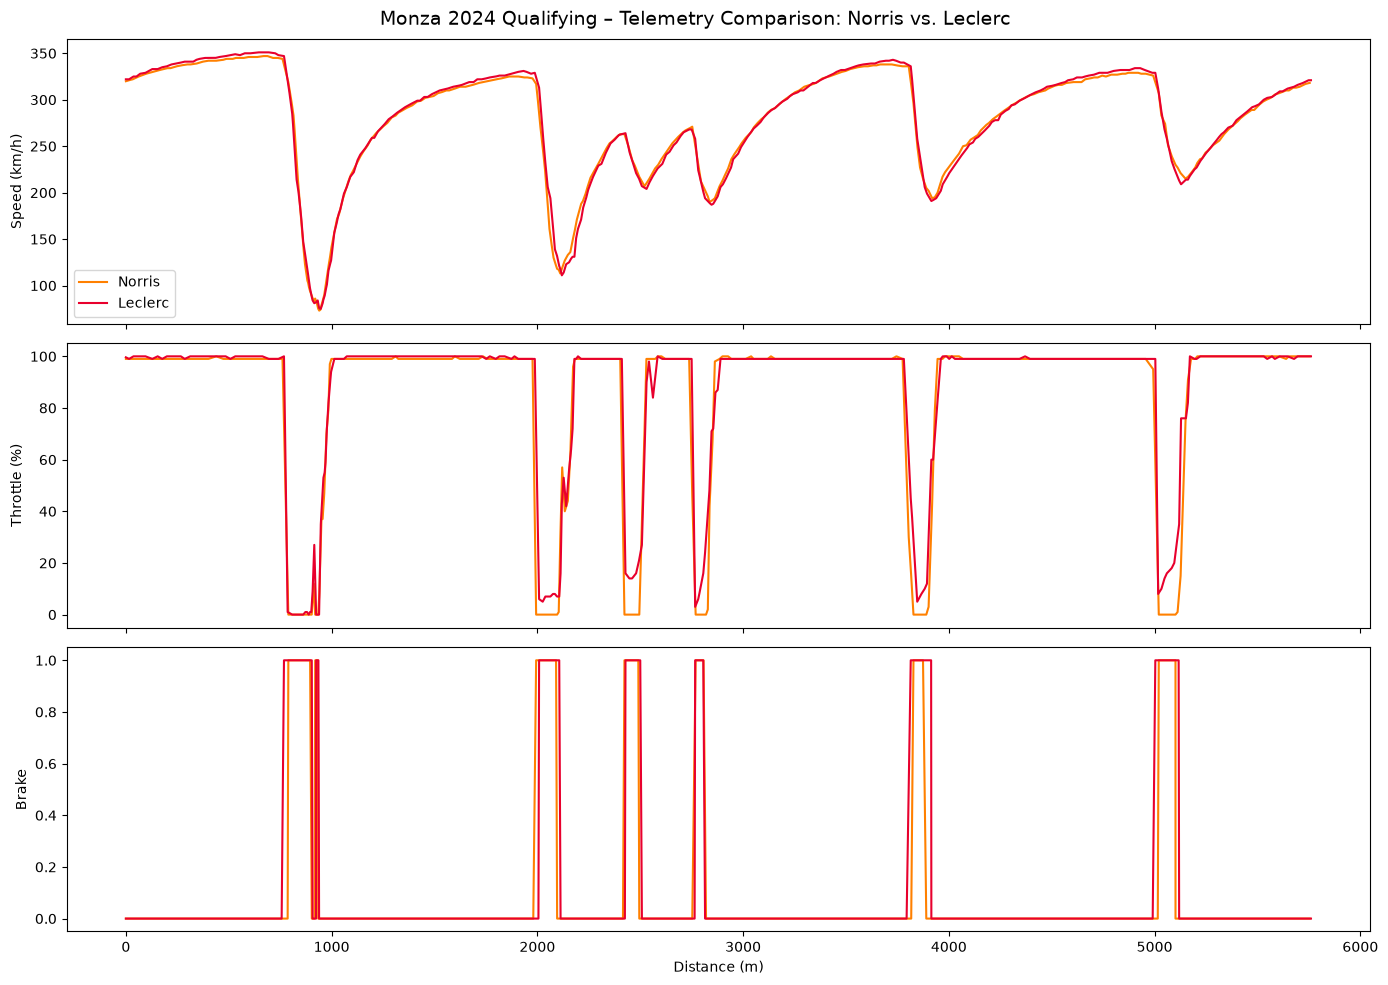

In [14]:
# Load telemetry for the fastest laps of Norris and Leclerc
nor = laps.pick_drivers("NOR").pick_fastest()
lec = laps.pick_drivers("LEC").pick_fastest()

tel_nor = nor.get_telemetry()
tel_lec = lec.get_telemetry()

# Plot speed, throttle and brake traces side by side
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

color_nor = fastf1.plotting.get_team_color("McLaren", session=session)
color_lec = fastf1.plotting.get_team_color("Ferrari", session=session)

# Speed
axes[0].plot(tel_nor["Distance"], tel_nor["Speed"], color=color_nor, label="Norris")
axes[0].plot(tel_lec["Distance"], tel_lec["Speed"], color=color_lec, label="Leclerc")
axes[0].set_ylabel("Speed (km/h)")
axes[0].legend()

# Throttle
axes[1].plot(tel_nor["Distance"], tel_nor["Throttle"], color=color_nor, label="Norris")
axes[1].plot(tel_lec["Distance"], tel_lec["Throttle"], color=color_lec, label="Leclerc")
axes[1].set_ylabel("Throttle (%)")

# Brake
axes[2].plot(tel_nor["Distance"], tel_nor["Brake"], color=color_nor, label="Norris")
axes[2].plot(tel_lec["Distance"], tel_lec["Brake"], color=color_lec, label="Leclerc")
axes[2].set_ylabel("Brake")
axes[2].set_xlabel("Distance (m)")

fig.suptitle("Monza 2024 Qualifying – Telemetry Comparison: Norris vs. Leclerc", fontsize=14)
plt.tight_layout()
plt.show()

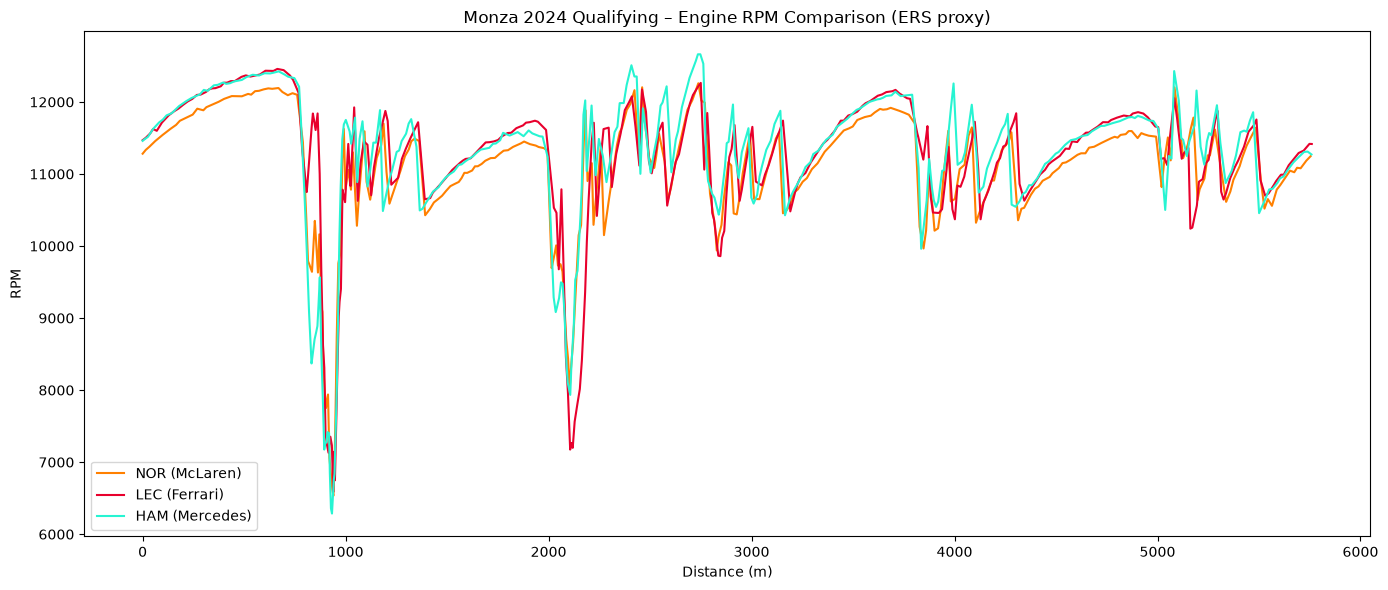

In [15]:
# Compare ERS deployment across top teams on a power circuit
# RPM serves as a proxy for ERS deployment zones
teams = {
    "NOR": "McLaren",
    "LEC": "Ferrari", 
    "HAM": "Mercedes"
}

fig, ax = plt.subplots(figsize=(14, 6))

# Load telemetry and plot RPM for each driver
for driver, team in teams.items():
    fastest = laps.pick_drivers(driver).pick_fastest()
    tel = fastest.get_telemetry()
    color = fastf1.plotting.get_team_color(team, session=session)
    ax.plot(tel["Distance"], tel["RPM"], color=color, label=f"{driver} ({team})")

ax.set_xlabel("Distance (m)")
ax.set_ylabel("RPM")
ax.set_title("Monza 2024 Qualifying – Engine RPM Comparison (ERS proxy)")
ax.legend()
plt.tight_layout()
plt.show()

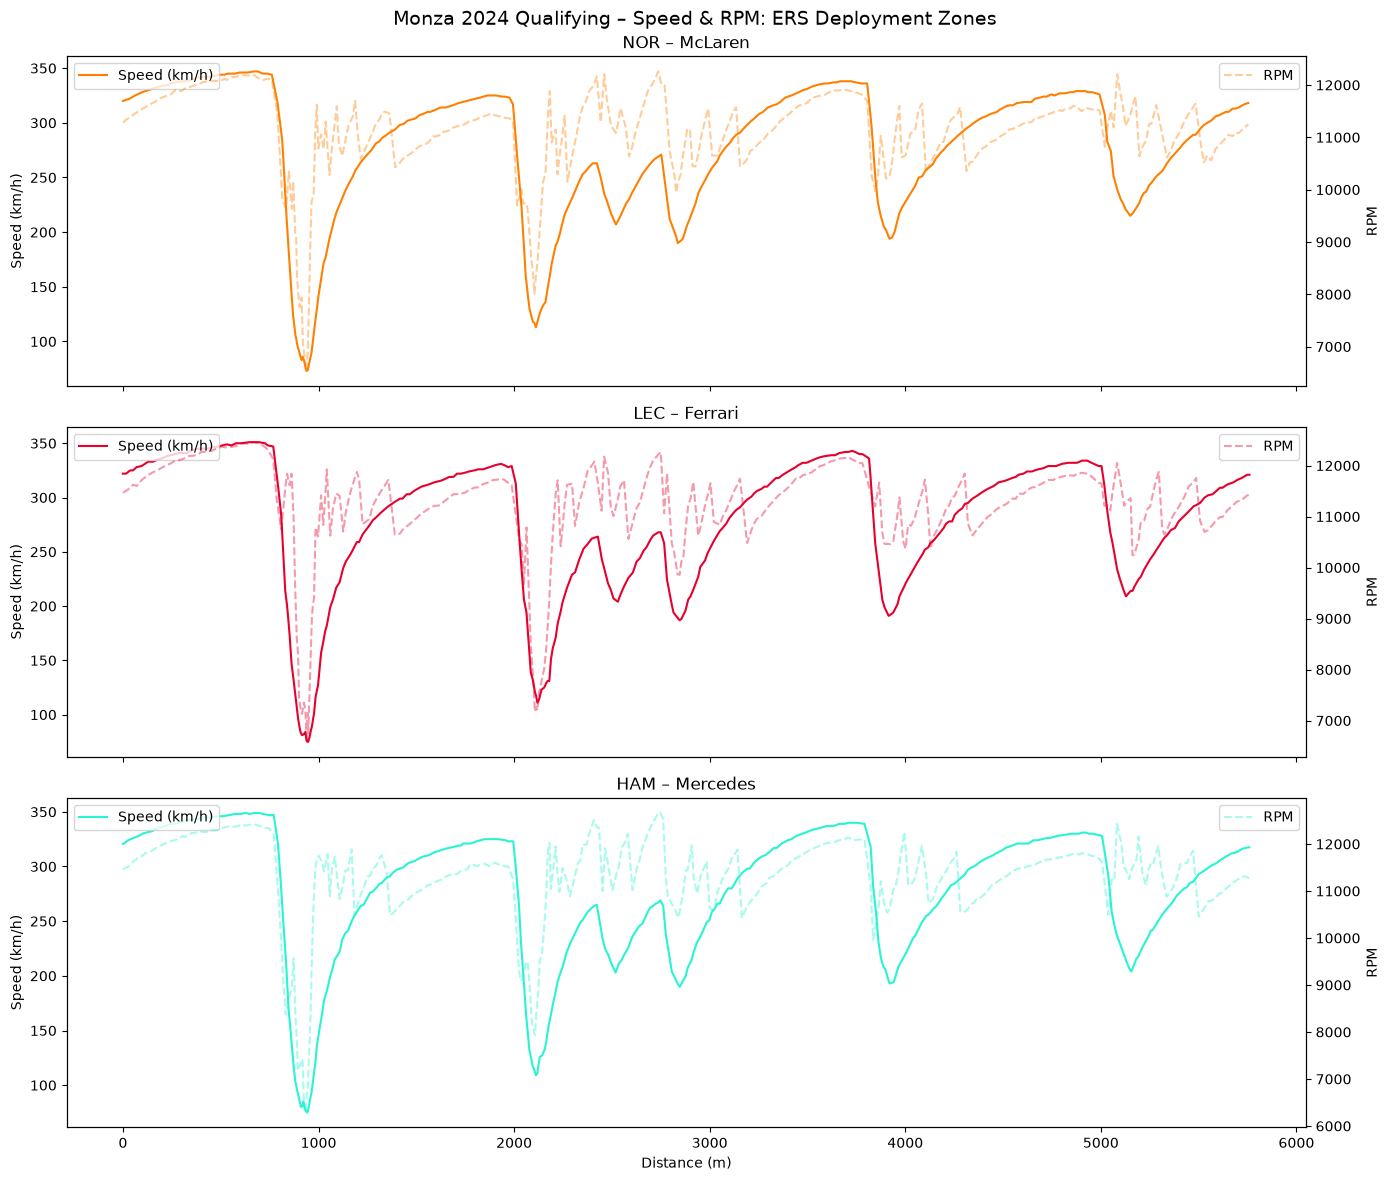

In [16]:
# Speed vs RPM to visualise ERS boost zones per team
teams = {
    "NOR": "McLaren",
    "LEC": "Ferrari",
    "HAM": "Mercedes"
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for i, (driver, team) in enumerate(teams.items()):
    fastest = laps.pick_drivers(driver).pick_fastest()
    tel = fastest.get_telemetry()
    color = fastf1.plotting.get_team_color(team, session=session)

    # Speed
    axes[i].plot(tel["Distance"], tel["Speed"], color=color, label="Speed (km/h)")
    axes[i].set_ylabel("Speed (km/h)")
    axes[i].set_title(f"{driver} – {team}")
    axes[i].legend(loc="upper left")

    # RPM on secondary axis
    ax2 = axes[i].twinx()
    ax2.plot(tel["Distance"], tel["RPM"], color=color, alpha=0.4, linestyle="--", label="RPM")
    ax2.set_ylabel("RPM")
    ax2.legend(loc="upper right")

axes[-1].set_xlabel("Distance (m)")
fig.suptitle("Monza 2024 Qualifying – Speed & RPM: ERS Deployment Zones", fontsize=14)
plt.tight_layout()
plt.show()